# ILLM — Lab 5: Word2Vec, fastText, Doc2Vec, and Clustering

**Corpus.** The training split built in **Lab 3** and also used by Lab 4 — IndicCorp v2, sentence
tokenised, with 1000-sentence dev and test sets. The files are loaded from `splits/` and verified
against Lab 3's manifest hash, so all three assignments provably share one dataset.
Run Lab 3 before this notebook.

### Tasks

| Task | What it asks | Section |
|---|---|---|
| 1a | Train Word2Vec on the training data | §4 |
| 1b | Train fastText on the training data | §5 |
| 1c | Train Doc2Vec on the training data | §6 |
| 2a | K-means over the word vectors; show the 20 words closest to each centroid | §8 |
| 2b | Represent dev/test sentences with word embeddings and with Doc2Vec; find the closest sentence for each | §10 |

Training follows the gensim tutorials referenced in the assignment
([word2vec](https://radimrehurek.com/gensim/auto_examples/tutorials/run_word2vec.html),
[fastText](https://radimrehurek.com/gensim/auto_examples/tutorials/run_fasttext.html),
[doc2vec](https://radimrehurek.com/gensim/auto_examples/tutorials/run_doc2vec_lee.html)).

---

### Relationship to Lab 4

This notebook **does not require you to have run Lab 4 first**, but it is much faster if you have:
it reuses the `indiccorp_<lang>_<N>.txt.gz` corpus cache that Lab 4 writes. If that file is
missing, the same streaming loader fetches it.

What it *does* require is that the split settings below (`LANGUAGE`, `PRESET`, `SEED`,
`SPLIT_RATIOS`, `MIN_LEN`, `MAX_LEN`, `LOWERCASE`, `STRIP_PUNCT`) match the values you used in
Lab 4. §3 verifies this automatically against Lab 4's `prep_*.npz` when that file is present, so a
mismatch is caught immediately rather than silently producing different splits.

### Runtime

Measured single-core throughput, scaled to the full corpus (~20M tokens). Divide by your core
count; Colab typically gives 2.

| Model | word-passes/s (1 core) | `full` (1M) | `quick` (100k) |
|---|---|---|---|
| Word2Vec sg=1 | ~187k | ~9 min | ~1 min |
| fastText sg=1 | ~95k | ~18 min | ~2 min |
| Doc2Vec dm=1 | ~233k | ~14 min | ~1.5 min |

Trained models are cached to disk, so re-running the notebook reloads them instead of retraining.
Start with `PRESET = "quick"` to check everything works end to end, then switch to `"full"`.

## 1. Setup

In [10]:
# gensim and scikit-learn are the only extra dependencies
try:
    import gensim, sklearn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gensim", "scikit-learn"])
    import gensim, sklearn

import os, gc, gzip, json, math, time, random, pickle, hashlib, logging
import unicodedata, itertools, multiprocessing
from pathlib import Path
try:
    import resource
except ImportError:
    resource = None
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec, FastText, Doc2Vec, KeyedVectors
from gensim.models.doc2vec import TaggedDocument
from gensim.models.word2vec import LineSentence
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.decomposition import PCA

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 90)

def rss_gb():
    if resource is None:
        return float("nan")
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6

print("gensim", gensim.__version__, "| sklearn", sklearn.__version__, "| numpy", np.__version__)
print("cores:", multiprocessing.cpu_count())

gensim 4.4.0 | sklearn 1.9.0 | numpy 2.3.5
cores: 12


In [11]:
# ==================================================================================
# CONFIGURATION
# ==================================================================================

# The corpus and the split come from Lab 3; Lab 4 uses the same files.
LANGUAGE    = "guj_Gujr"             # must match Lab 3
N_SENTENCES = None                   # filled in from the Lab 3 manifest

LOWERCASE, STRIP_PUNCT = True, True
MIN_LEN, MAX_LEN       = 1, 200
SEED                   = 42

# Resolve paths from the repository rather than the notebook kernel's working directory.
WORKSPACE_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "Assignment3" / "lab3_out" / "splits").is_dir()),
    None,
)
if WORKSPACE_ROOT is None:
    raise FileNotFoundError(
        "Could not locate Assignment3/lab3_out/splits from the current working directory. "
        "Open this notebook inside the ILLM workspace."
    )
LAB3_OUTPUT_DIR = WORKSPACE_ROOT / "Assignment3" / "lab3_out"
CACHE_DIR = str(LAB3_OUTPUT_DIR)
SAVE_DIR = str(WORKSPACE_ROOT / "Assignment5" / "models")

# ---- embedding hyper-parameters (shared where possible, so the comparison is fair) ----
VECTOR_SIZE = 100
WINDOW      = 5
MIN_COUNT   = 5        # gensim's own frequency cutoff; unrelated to Lab 4's <UNK> policy
NEGATIVE    = 5
SAMPLE      = 1e-3     # frequent-word subsampling
SG          = 1        # 1 = skip-gram, 0 = CBOW.  CBOW is roughly 2x faster.
EPOCHS      = 5
WORKERS     = max(1, multiprocessing.cpu_count())

FT_BUCKET   = 500_000  # character-ngram hash buckets (gensim default 2M costs 4x the RAM)
FT_MIN_N    = 3
FT_MAX_N    = 6

D2V_DM      = 1        # 1 = PV-DM (distributed memory), 0 = PV-DBOW
D2V_EPOCHS  = 10       # Doc2Vec benefits from more passes than Word2Vec
D2V_INFER_EPOCHS = 20  # passes used by infer_vector on unseen sentences

# ---- task 2a: clustering ----------------------------------------------------------
K_CLUSTERS        = 50
CLUSTER_TOP_WORDS = 50_000   # cluster the N most frequent words (0 = the whole vocabulary)
WORDS_PER_CLUSTER = 20       # the assignment asks for 20
KMEANS_BATCH      = 10_000

# ---- task 2b: nearest-sentence search --------------------------------------------
NN_POOL    = 20_000   # candidate sentences the search runs over
NN_QUERIES = 1_000    # dev/test sentences used as queries (None = all of them)

# Where the "closest sentence" is looked for:
#   "self"  -> within the same split (the literal reading of the assignment)
#   "train" -> among training sentences, which also lets Doc2Vec use its learned dv vectors
NN_POOL_SOURCE = "self"

# Averaged word vectors share a large common direction, which makes every pair look ~0.99
# similar and destroys the ranking. Subtracting the pool mean before normalising fixes it.
CENTER_SENTENCE_VECTORS = True
NN_SHOW    = 5        # worked examples printed in full

# ---- caching ----------------------------------------------------------------------
MODEL_CACHE = True    # reload trained models from disk instead of retraining

random.seed(SEED)
np.random.seed(SEED)
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"workspace root: {WORKSPACE_ROOT}")
print(f"language {LANGUAGE}  (corpus and splits come from Lab 3)")
print(f"dim {VECTOR_SIZE} | window {WINDOW} | min_count {MIN_COUNT} | "
      f"{'skip-gram' if SG else 'CBOW'} | epochs {EPOCHS} | workers {WORKERS}")

workspace root: e:\Coding\ILLM
language guj_Gujr  (corpus and splits come from Lab 3)
dim 100 | window 5 | min_count 5 | skip-gram | epochs 5 | workers 12


## 2. Corpus — the splits built in Lab 3

Lab 5 trains on *the training data from the previous assignment*, which is the split Lab 3 wrote
and Lab 4 also consumes. Nothing is streamed or re-split here: the three files are loaded and
checked against Lab 3's manifest hash.

In [12]:
# ==================================================================================
# CORPUS — the canonical splits produced by Lab 3
# ==================================================================================
SPLIT_DIR = os.path.join(CACHE_DIR, "splits")
SPLIT_FILES = {
    "train": os.path.join(SPLIT_DIR, f"{LANGUAGE}_train.txt.gz"),
    "dev":   os.path.join(SPLIT_DIR, f"{LANGUAGE}_dev.txt"),
    "test":  os.path.join(SPLIT_DIR, f"{LANGUAGE}_test.txt"),
}
MANIFEST = os.path.join(SPLIT_DIR, f"{LANGUAGE}_manifest.json")
LAB4_PREP = WORKSPACE_ROOT / "Assignment4" / "prep_guj_Gujr_fa6d490de0.npz"


def read_split(path):
    opener = (lambda p: gzip.open(p, "rt", encoding="utf-8")) if path.endswith(".gz") \
             else (lambda p: open(p, encoding="utf-8"))
    with opener(path) as f:
        return [ln.rstrip("\n") for ln in f if ln.strip()]


def sha256_of(lines):
    h = hashlib.sha256()
    for ln in lines:
        h.update(ln.encode("utf-8"))
        h.update(b"\n")
    return h.hexdigest()


missing = [p for p in list(SPLIT_FILES.values()) + [MANIFEST] if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        "Lab 3 output not found: " + ", ".join(missing) +
        "\nRun ILLM_Lab3_Tokenization.ipynb first (same LANGUAGE and PRESET)."
    )

train_raw = read_split(SPLIT_FILES["train"])
dev_raw   = read_split(SPLIT_FILES["dev"])
test_raw  = read_split(SPLIT_FILES["test"])
with open(MANIFEST, encoding="utf-8") as f:
    lab3 = json.load(f)

ok = True
for name, lines in (("train", train_raw), ("dev", dev_raw), ("test", test_raw)):
    match = (len(lines) == lab3[f"{name}_sentences"]) and (sha256_of(lines) == lab3["sha256"][name])
    ok &= match
    print(f"  {name:<5} {len(lines):>9,} sentences   {'verified' if match else 'MISMATCH'}")
assert ok, "Split files do not match the Lab 3 manifest — re-run Lab 3."

N_SENTENCES = lab3["total_sentences"]
SPLIT_HASH = lab3["sha256"]["train"][:10]
print(f"\nusing the Lab 3 splits (preset='{lab3['preset']}', language='{lab3['language']}')")
print("Lab 4 trains its n-gram models on this same training split.")

if LAB4_PREP.exists():
    with np.load(LAB4_PREP) as prep:
        lab4_counts = {
            "train": len(prep["train_lens"]),
            "dev": len(prep["dev_lens"]),
            "test": len(prep["test_lens"]),
        }
    assert lab4_counts["dev"] == lab3["dev_sentences"]
    assert lab4_counts["test"] == lab3["test_sentences"]
    assert 0 < lab4_counts["train"] <= lab3["train_sentences"]
    if lab4_counts["train"] != lab3["train_sentences"]:
        print(f"Lab 4 preparation verified for dev/test; its preprocessing retained "
              f"{lab4_counts['train']:,}/{lab3['train_sentences']:,} training sentences.")
    else:
        print(f"Lab 4 preparation verified: {LAB4_PREP}")
else:
    print(f"Lab 4 preparation not found (skipping optional check): {LAB4_PREP}")

  train   998,000 sentences   verified
  dev       1,000 sentences   verified
  test      1,000 sentences   verified

using the Lab 3 splits (preset='full', language='guj_Gujr')
Lab 4 trains its n-gram models on this same training split.
Lab 4 preparation verified for dev/test; its preprocessing retained 997,986/998,000 training sentences.


In [13]:
# --- identical tokenizer to Lab 4 ---
class _PunctTable(dict):
    def __missing__(self, cp):
        ch = chr(cp)
        v = " " if unicodedata.category(ch)[0] in ("P", "S") else ch
        self[cp] = v
        return v

PUNCT_TABLE = _PunctTable()
ZERO_WIDTH = dict.fromkeys(map(ord, "\u200b\u200c\u200d\ufeff"), None)


def tokenize(sentence):
    s = unicodedata.normalize("NFC", sentence).translate(ZERO_WIDTH)
    if STRIP_PUNCT:
        s = s.translate(PUNCT_TABLE)
    if LOWERCASE:
        s = s.lower()
    return s.split()

print("tokenizer ready — same normalisation Lab 4 uses")
demo = train_raw[0]
print("RAW :", demo[:120])
print("TOK :", tokenize(demo)[:15])

tokenizer ready — same normalisation Lab 4 uses
RAW : આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ
TOK : ['આ', 'વીડિયો', 'જુઓ', 'ઊંઝા', 'માર્કેટયાર્ડ', 'આજથી', '25', 'જુલાઈ', 'સુધી', 'બંધ']


## 3. Tokenized corpus files (and a check that the split matches Lab 4)

gensim streams its training data from disk, one space-separated sentence per line, so we write
the tokenized splits once to gzipped text. Every epoch then costs a `str.split()` per line
instead of a full Unicode normalisation pass.

If Lab 4's `prep_*.npz` is present, the per-split sentence counts and token counts are compared
against it. They must agree exactly — that is the guarantee that both assignments use the same
training data.

In [14]:
def write_tokens(raw_list, path):
    kept_lens = []
    with gzip.open(path, "wt", encoding="utf-8", compresslevel=6) as f:
        for s in raw_list:
            t = tokenize(s)
            if MIN_LEN <= len(t) <= MAX_LEN:
                f.write(" ".join(t) + "\n")
                kept_lens.append(len(t))
    return np.array(kept_lens, dtype=np.int32)


TOK_PATHS = {name: os.path.join(CACHE_DIR, f"tokens_{LANGUAGE}_{SPLIT_HASH}_{name}.txt.gz")
             for name in ("train", "dev", "test")}
LEN_PATH = os.path.join(CACHE_DIR, f"tokens_{LANGUAGE}_{SPLIT_HASH}_lens.npz")

if all(os.path.exists(p) for p in TOK_PATHS.values()) and os.path.exists(LEN_PATH):
    z = np.load(LEN_PATH)
    split_lens = {k: z[k] for k in ("train", "dev", "test")}
    print("Reusing tokenized corpus cache:")
else:
    t0 = time.time()
    split_lens = {}
    for name, raws in [("train", train_raw), ("dev", dev_raw), ("test", test_raw)]:
        split_lens[name] = write_tokens(raws, TOK_PATHS[name])
        print(f"  wrote {name:5s} {len(split_lens[name]):>9,} sentences  "
              f"({os.path.getsize(TOK_PATHS[name])/1e6:.0f} MB)")
    np.savez_compressed(LEN_PATH, **split_lens)
    print(f"  tokenized in {time.time()-t0:.0f}s")

for name in ("train", "dev", "test"):
    L = split_lens[name]
    print(f"  {name:5s} {len(L):>9,} sentences | {int(L.sum()):>12,} tokens | "
          f"mean length {L.mean():.1f} | {os.path.getsize(TOK_PATHS[name])/1e6:>5.0f} MB")

  wrote train   997,986 sentences  (55 MB)
  wrote dev       1,000 sentences  (0 MB)
  wrote test      1,000 sentences  (0 MB)
  tokenized in 48s
  train   997,986 sentences |   15,210,546 tokens | mean length 15.2 |    55 MB
  dev       1,000 sentences |       29,821 tokens | mean length 29.8 |     0 MB
  test      1,000 sentences |       29,886 tokens | mean length 29.9 |     0 MB


## 4. Task 1a — Word2Vec

Skip-gram with negative sampling, following the gensim tutorial. The model learns one vector per
vocabulary word by predicting context words from the centre word; words appearing in similar
contexts end up with similar vectors.

Words below `MIN_COUNT` occurrences are discarded (gensim's own cutoff), and frequent words are
subsampled at rate `SAMPLE` — without that, function words dominate the gradient updates and
contribute almost nothing to the representation.

In [15]:
logging.basicConfig(format="%(asctime)s %(levelname)s: %(message)s", level=logging.WARNING)

COMMON = dict(vector_size=VECTOR_SIZE, window=WINDOW, min_count=MIN_COUNT,
              sg=SG, negative=NEGATIVE, sample=SAMPLE, workers=WORKERS, seed=SEED)

W2V_PATH = os.path.join(SAVE_DIR, f"w2v_{LANGUAGE}_{SPLIT_HASH}_d{VECTOR_SIZE}.model")

if MODEL_CACHE and os.path.exists(W2V_PATH):
    t0 = time.time()
    w2v = Word2Vec.load(W2V_PATH)
    print(f"Loaded cached Word2Vec from {W2V_PATH} ({time.time()-t0:.1f}s)")
else:
    t0 = time.time()
    w2v = Word2Vec(sentences=LineSentence(TOK_PATHS["train"]), epochs=EPOCHS, **COMMON)
    dt = time.time() - t0
    w2v.save(W2V_PATH)
    print(f"Trained Word2Vec in {dt/60:.1f} min "
          f"({w2v.corpus_total_words*EPOCHS/dt/1000:,.0f}k word-passes/s)")

print(f"\nVocabulary        : {len(w2v.wv):,} words")
print(f"Vector size       : {w2v.wv.vector_size}")
print(f"Training tokens   : {w2v.corpus_total_words:,}")
print(f"Model matrix      : {w2v.wv.vectors.nbytes/1e6:.0f} MB   |  RSS {rss_gb():.2f} GB")

Trained Word2Vec in 1.7 min (755k word-passes/s)

Vocabulary        : 113,867 words
Vector size       : 100
Training tokens   : 15,210,546
Model matrix      : 46 MB   |  RSS nan GB


## 5. Task 1b — fastText

Same objective as Word2Vec, but a word's vector is the sum of the vectors of its character
n-grams (length `FT_MIN_N`..`FT_MAX_N`) plus a whole-word vector. Two consequences matter for
Indic languages specifically:

* **Morphology is shared.** Hindi, Tamil, Malayalam and friends are far more inflected than
  English, so a word's suffixes carry real grammatical information that Word2Vec has to relearn
  from scratch for every surface form.
* **No OOV problem.** An unseen word still gets a vector, assembled from its n-grams. This is
  measured in §7.

`FT_BUCKET` sets how many hash buckets the character n-grams share. gensim's default of 2,000,000
would allocate 2M x 100 x 4 bytes = 800 MB for the n-gram matrix alone (twice that during
training), so it is reduced here.

In [16]:
FT_PATH = os.path.join(SAVE_DIR, f"ft_{LANGUAGE}_{SPLIT_HASH}_d{VECTOR_SIZE}.model")

if MODEL_CACHE and os.path.exists(FT_PATH):
    t0 = time.time()
    ft = FastText.load(FT_PATH)
    print(f"Loaded cached fastText from {FT_PATH} ({time.time()-t0:.1f}s)")
else:
    t0 = time.time()
    ft = FastText(sentences=LineSentence(TOK_PATHS["train"]), epochs=EPOCHS,
                  bucket=FT_BUCKET, min_n=FT_MIN_N, max_n=FT_MAX_N, **COMMON)
    dt = time.time() - t0
    ft.save(FT_PATH)
    print(f"Trained fastText in {dt/60:.1f} min "
          f"({ft.corpus_total_words*EPOCHS/dt/1000:,.0f}k word-passes/s)")

print(f"\nVocabulary        : {len(ft.wv):,} words")
print(f"Word matrix       : {ft.wv.vectors.nbytes/1e6:.0f} MB")
print(f"N-gram matrix     : {ft.wv.vectors_ngrams.nbytes/1e6:.0f} MB "
      f"({FT_BUCKET:,} buckets)")
print(f"RSS {rss_gb():.2f} GB")

Trained fastText in 3.1 min (414k word-passes/s)

Vocabulary        : 113,867 words
Word matrix       : 46 MB
N-gram matrix     : 200 MB (500,000 buckets)
RSS nan GB


## 6. Task 1c — Doc2Vec

PV-DM (`dm=1`): each *sentence* gets its own vector, trained jointly with the word vectors by
using the sentence vector as an extra piece of context. Every training sentence is tagged with
its index, so the model ends up with `len(train)` document vectors.

Sentences the model has never seen (dev and test) get vectors from `infer_vector`, which freezes
the learned weights and runs gradient descent on a fresh document vector alone. That is the
method used for §10.

In [17]:
class TaggedCorpus:
    # streams TaggedDocuments from the gzipped token file, one pass per epoch
    def __init__(self, path):
        self.path = path
    def __iter__(self):
        with gzip.open(self.path, "rt", encoding="utf-8") as f:
            for i, line in enumerate(f):
                yield TaggedDocument(line.split(), [i])


D2V_PATH = os.path.join(SAVE_DIR, f"d2v_{LANGUAGE}_{SPLIT_HASH}_d{VECTOR_SIZE}.model")

if MODEL_CACHE and os.path.exists(D2V_PATH):
    t0 = time.time()
    d2v = Doc2Vec.load(D2V_PATH)
    print(f"Loaded cached Doc2Vec from {D2V_PATH} ({time.time()-t0:.1f}s)")
else:
    t0 = time.time()
    d2v = Doc2Vec(TaggedCorpus(TOK_PATHS["train"]), dm=D2V_DM, epochs=D2V_EPOCHS,
                  vector_size=VECTOR_SIZE, window=WINDOW, min_count=MIN_COUNT,
                  negative=NEGATIVE, sample=SAMPLE, workers=WORKERS, seed=SEED)
    dt = time.time() - t0
    d2v.save(D2V_PATH)
    print(f"Trained Doc2Vec in {dt/60:.1f} min")

print(f"\nDocument vectors  : {len(d2v.dv):,}")
print(f"Word vocabulary   : {len(d2v.wv):,}")
print(f"Doc matrix        : {d2v.dv.vectors.nbytes/1e6:.0f} MB   |  RSS {rss_gb():.2f} GB")

Trained Doc2Vec in 17.6 min

Document vectors  : 997,986
Word vocabulary   : 113,867
Doc matrix        : 399 MB   |  RSS nan GB


## 7. Are the models any good? — qualitative and quantitative checks

Three checks before using the vectors for anything:

1. **Nearest neighbours** of a few frequent words — the cheapest way to see whether the space is
   meaningful at all.
2. **Vocabulary coverage** of dev/test — how many tokens Word2Vec simply cannot represent, and
   how fastText's subwords change that number.
3. **Doc2Vec self-similarity**: re-infer a vector for a *training* sentence and check how often
   the most similar document vector is the sentence itself. This is the sanity check from the
   gensim Lee tutorial; a healthy model scores near 100%.

In [18]:
probe_words = [w for w in w2v.wv.index_to_key[20:400:60]][:6]
rows = []
for w in probe_words:
    rows.append({"word": w,
                 "Word2Vec neighbours": ", ".join(x for x, _ in w2v.wv.most_similar(w, topn=6)),
                 "fastText neighbours": ", ".join(x for x, _ in ft.wv.most_similar(w, topn=6))})
display(pd.DataFrame(rows).set_index("word"))

,Word2Vec neighbours,fastText neighbours
word,,
જે,"તે, જેના, જેને, જેમાં, પરંતુ, તેથી","તે, તેથી, જેના, પરંતુ, જેમાં, અને"
સૌથી,"સોથી, સોૈથી, ક્રમની, વિશ્ર્વનું, મોટામાં, વિશ્વનો","સૌથીવધુ, એકમાત્ર, વિશ્વની, વિશ્વનો, બહુ, સોૈથી"
કેસ,"કેસો, નોંધાયા, મામલા, પોઝિટિવના, કેસમાંથી, કેસનો","કેસો, કેસોમા, કેસઃ, નોંધાયા, મામલા, કેસોની"
અહીં,"અહી, અહીંયા, અહિં, અહિયાં, અહિંયા, પુનઃપ્રકાશિત","અહી, અહીંયા, અહીંયાં, અહિંયા, અહિયાં, અહિં"
હેઠળ,"અંતર્ગત, હેઠળના, હેઠળની, અન્વયે, તળે, એક્ટ","અંતર્ગત, હેઠળના, હેઠલ, હેઠળની, અતર્ગત, હેઠળનો"
આપવા,"લેવા, મળવા, મોકલવા, આપવાની, આપવાનો, લાવવા","આપવાં, અપાવવા, લોભાવવા, મોકલાવવા, લેવા, આપત"


In [19]:
def read_tokens(path, limit=None):
    out = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if limit is not None and i >= limit:
                break
            out.append(line.split())
    return out


COV_SAMPLE = min(20_000, len(split_lens["dev"]))
dev_tokens_sample = read_tokens(TOK_PATHS["dev"], COV_SAMPLE)
flat = [w for s in dev_tokens_sample for w in s]
w2v_vocab = set(w2v.wv.key_to_index)
ft_vocab = set(ft.wv.key_to_index)

in_w2v = sum(w in w2v_vocab for w in flat)
types = set(flat)
rows = [
    {"model": "Word2Vec", "token coverage %": round(100 * in_w2v / len(flat), 2),
     "type coverage %": round(100 * sum(t in w2v_vocab for t in types) / len(types), 2),
     "can embed OOV?": "no"},
    {"model": "fastText", "token coverage %": round(100 * sum(w in ft_vocab for w in flat) / len(flat), 2),
     "type coverage %": round(100 * sum(t in ft_vocab for t in types) / len(types), 2),
     "can embed OOV?": "yes (character n-grams)"},
]
print(f"Dev vocabulary coverage over {len(flat):,} tokens / {len(types):,} types "
      f"({COV_SAMPLE:,} sentences)")
display(pd.DataFrame(rows).set_index("model"))

oov = [t for t in types if t not in w2v_vocab][:5]
if oov:
    print("Example out-of-vocabulary dev words and their nearest fastText neighbours:")
    for w in oov:
        try:
            print(f"  {w:<25} -> {', '.join(x for x, _ in ft.wv.most_similar(w, topn=5))}")
        except Exception as e:
            print(f"  {w:<25} -> ({e})")

Dev vocabulary coverage over 29,821 tokens / 10,909 types (1,000 sentences)


,token coverage %,type coverage %,can embed OOV?
model,,,
Word2Vec,94.88,86.42,no
fastText,94.88,86.42,yes (character n-grams)


Example out-of-vocabulary dev words and their nearest fastText neighbours:
  રફ્ી                      -> ચીલઝડપ, લૂંટફાટની, ગાંધીધામની, વીજચોરી, રફ્તાર
  foretold                  -> distinguished, regional, corrigendum, training, 5th
  237ચોરસ                   -> ચોરસ, લંબચોરસ, ચોરસમીટર, ચોરસફૂટ, મલ્ટિમીટર
  ઘોડાધ્રોઈ                 -> ઘોડાસર, કાલાઘોડા, ભીલોડા, ઘોડાસરા, ત્રંબા
  સલાહસૂચનો                 -> સૂચનો, સલાહનો, સૂચનોનો, નિષ્ણાતનો, સુચનો


In [20]:
# Doc2Vec self-similarity check (gensim Lee-corpus style)
SELF_CHECK = min(500, len(split_lens["train"]))
train_head = read_tokens(TOK_PATHS["train"], SELF_CHECK)

ranks = []
t0 = time.time()
for i, toks in enumerate(train_head):
    v = d2v.infer_vector(toks, epochs=D2V_INFER_EPOCHS)
    sims = d2v.dv.most_similar([v], topn=len(d2v.dv))
    ranks.append([docid for docid, _ in sims].index(i))
ranks = np.array(ranks)
print(f"Doc2Vec self-similarity over {SELF_CHECK} training sentences ({time.time()-t0:.0f}s)")
print(f"  rank 0 (most similar document is itself) : {100*np.mean(ranks == 0):.1f}%")
print(f"  rank < 5                                 : {100*np.mean(ranks < 5):.1f}%")
print(f"  median rank                              : {int(np.median(ranks))}")
print("\nA high rank-0 percentage means the document vectors are specific to their sentences;")
print("a low one means the model has under-trained or the vectors have collapsed.")

Doc2Vec self-similarity over 500 training sentences (462s)
  rank 0 (most similar document is itself) : 79.8%
  rank < 5                                 : 84.6%
  median rank                              : 0

A high rank-0 percentage means the document vectors are specific to their sentences;
a low one means the model has under-trained or the vectors have collapsed.


## 8. Task 2a — K-means clustering of the word vectors

Clustering runs on the `CLUSTER_TOP_WORDS` most frequent words. Restricting to frequent words is
deliberate: the tail of the vocabulary consists largely of words seen 5–10 times, whose vectors
are dominated by noise and which would otherwise form large, meaningless clusters.

**Vectors are L2-normalised before clustering.** K-means minimises Euclidean distance, and on
normalised vectors that is a monotone function of cosine distance
($\|a-b\|^2 = 2 - 2\cos(a,b)$) — which is the similarity word embeddings actually encode. Without
normalisation, clusters largely track vector *magnitude*, which mostly reflects word frequency.

Each cluster is then represented by the `WORDS_PER_CLUSTER` words whose vectors are closest to
its centroid, as the assignment asks.

In [21]:
def cluster_words(kv, k=K_CLUSTERS, top_words=CLUSTER_TOP_WORDS, tag=""):
    words = kv.index_to_key[:top_words] if top_words else list(kv.index_to_key)
    X = np.asarray([kv[w] for w in words], dtype=np.float32)
    X /= (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)

    t0 = time.time()
    km = MiniBatchKMeans(n_clusters=k, random_state=SEED, batch_size=KMEANS_BATCH,
                         n_init=5, max_iter=200)
    labels = km.fit_predict(X)
    C = km.cluster_centers_.astype(np.float32)
    C /= (np.linalg.norm(C, axis=1, keepdims=True) + 1e-9)
    print(f"{tag}: clustered {len(words):,} words into {k} clusters in {time.time()-t0:.1f}s "
          f"(inertia {km.inertia_:,.0f})")

    sims = X @ C.T                      # cosine similarity of every word to every centroid
    members = []
    for c in range(k):
        idx = np.flatnonzero(labels == c)
        if len(idx) == 0:
            members.append([])
            continue
        best = idx[np.argsort(-sims[idx, c])][:WORDS_PER_CLUSTER]
        members.append([words[i] for i in best])
    return {"words": words, "X": X, "labels": labels, "centroids": C,
            "members": members, "model": km}


w2v_clusters = cluster_words(w2v.wv, tag="Word2Vec")
ft_clusters  = cluster_words(ft.wv,  tag="fastText")

Word2Vec: clustered 50,000 words into 50 clusters in 2.0s (inertia 22,326)
fastText: clustered 50,000 words into 50 clusters in 1.8s (inertia 24,366)


### 8.1 K-means, written out

The assignment says to *use* K-means rather than to implement it, so the grid above calls
scikit-learn. Still, the clustering is the substance of task 2a, so Lloyd's algorithm with
k-means++ seeding is written out below and checked against the library.

K-means is non-convex and both implementations start from a random seeding, so identical cluster
labels are not the right expectation. The meaningful comparison is **inertia**: if the two land on
solutions of the same quality, the implementation is sound.

In [22]:
# ---------------------------------------------------------------------------------
# K-means written out, so the clustering step does not rest entirely on a library call
# ---------------------------------------------------------------------------------
def _kmeans_once(X, k, rng, max_iter, tol):
    n = len(X)
    sq = (X ** 2).sum(1)

    # --- k-means++ initialisation: spread the initial centroids out ---
    centres = np.empty((k, X.shape[1]), dtype=np.float32)
    centres[0] = X[rng.integers(n)]
    closest = ((X - centres[0]) ** 2).sum(1)
    for j in range(1, k):
        probs = closest / max(closest.sum(), 1e-12)
        centres[j] = X[rng.choice(n, p=probs)]
        closest = np.minimum(closest, ((X - centres[j]) ** 2).sum(1))

    # --- alternate assignment and update until the centroids stop moving ---
    labels = np.zeros(n, dtype=np.int32)
    prev = None
    for it in range(max_iter):
        # ||x-c||^2 = ||x||^2 - 2x.c + ||c||^2; the ||x||^2 term does not change the argmin
        d = (centres ** 2).sum(1)[None, :] - 2.0 * (X @ centres.T)
        labels = np.argmin(d, axis=1).astype(np.int32)
        inertia = float((d[np.arange(n), labels] + sq).sum())

        for j in range(k):
            m = labels == j
            if m.any():
                centres[j] = X[m].mean(0)
            else:                                   # empty cluster -> reseed on the worst point
                centres[j] = X[np.argmax(d[np.arange(n), labels])]

        # converged once the objective stops improving (skip on the first pass, where
        # there is nothing to compare against)
        if prev is not None and abs(prev - inertia) <= tol * max(abs(prev), 1.0):
            break
        prev = inertia
    return labels, centres, inertia, it + 1


def kmeans_scratch(X, k, seed=SEED, max_iter=100, tol=1e-6, n_init=10):
    """Lloyd's algorithm with k-means++ seeding, restarted `n_init` times.

    X is assumed L2-normalised, so Euclidean distance is a monotone function of cosine
    distance. Restarting matters: k-means is non-convex, and a single run from an unlucky
    seeding lands well short of the best solution — which is exactly why sklearn defaults
    to 10 restarts too.
    """
    rng = np.random.default_rng(seed)
    best = None
    for _ in range(n_init):
        out = _kmeans_once(X, k, rng, max_iter, tol)
        if best is None or out[2] < best[2]:
            best = out
    return best


# --- does it agree with the library? ---
from sklearn.metrics import adjusted_rand_score

_X = w2v_clusters["X"]
_k = K_CLUSTERS
t0 = time.time()
s_labels, s_centres, s_inertia, s_iters = kmeans_scratch(_X, _k)
t_scratch = time.time() - t0

t0 = time.time()
_ref = KMeans(n_clusters=_k, random_state=SEED, n_init=10).fit(_X)
t_lib = time.time() - t0

ari = adjusted_rand_score(_ref.labels_, s_labels)
print(f"scratch K-means : inertia {s_inertia:,.1f}  ({s_iters} iterations, {t_scratch:.1f}s)")
print(f"sklearn KMeans  : inertia {_ref.inertia_:,.1f}  ({t_lib:.1f}s)")
print(f"inertia ratio   : {s_inertia/max(_ref.inertia_,1e-9):.4f}   (1.00 = equally good solution)")
print(f"adjusted Rand   : {ari:.3f}   (agreement between the two partitions)")
print("\nK-means is non-convex, so identical labels are not expected — matching inertia is the\n"
      "meaningful check. The experiments below use the library version for speed; set\n"
      "USE_SCRATCH_KMEANS = True to drive the reported clusters from the implementation above.")

USE_SCRATCH_KMEANS = False
if USE_SCRATCH_KMEANS:
    C = s_centres / (np.linalg.norm(s_centres, axis=1, keepdims=True) + 1e-9)
    sims = _X @ C.T
    w2v_clusters["labels"], w2v_clusters["centroids"] = s_labels, C
    w2v_clusters["members"] = [
        [w2v_clusters["words"][i] for i in np.flatnonzero(s_labels == c)[
            np.argsort(-sims[np.flatnonzero(s_labels == c), c])][:WORDS_PER_CLUSTER]]
        if (s_labels == c).any() else []
        for c in range(_k)]
    print("\nReported Word2Vec clusters now come from the from-scratch implementation.")

scratch K-means : inertia 21,907.9  (80 iterations, 22.7s)
sklearn KMeans  : inertia 21,889.7  (10.0s)
inertia ratio   : 1.0008   (1.00 = equally good solution)
adjusted Rand   : 0.673   (agreement between the two partitions)

K-means is non-convex, so identical labels are not expected — matching inertia is the
meaningful check. The experiments below use the library version for speed; set
USE_SCRATCH_KMEANS = True to drive the reported clusters from the implementation above.


In [23]:
def cluster_table(res, n_show=None):
    rows = []
    for c, ws in enumerate(res["members"]):
        rows.append({"cluster": c,
                     "size": int(np.sum(res["labels"] == c)),
                     f"top {WORDS_PER_CLUSTER} words closest to centroid": "  ".join(ws)})
    df = pd.DataFrame(rows).set_index("cluster")
    return df.head(n_show) if n_show else df

print(f"WORD2VEC — {K_CLUSTERS} clusters, {WORDS_PER_CLUSTER} words closest to each centroid")
with pd.option_context("display.max_colwidth", 400, "display.max_rows", 200):
    display(cluster_table(w2v_clusters))

WORD2VEC — 50 clusters, 20 words closest to each centroid


,size,top 20 words closest to centroid
cluster,,
0,1060,પૂછશો જાણશે બકા અંતરાત્મા કાઢશો માનશો જણાવશો ઇમાનદારીથી મૂર્ખતા જણાવીશ સાંભળશો લાવીશ પ્રામાણિકપણે સમજાશે બીજાઓને શીખવો મજામાં વર્તવું બોલીએ વાંચશો
1,523,આરપીએફ પોલિસની ફાયટર સ્કવોર્ડ વાનની બીએસએફની સાંતાક્રુઝ સ્ટેશનનાં હેડક્વાર્ટરમાં srp એમ્બ્યુલન્સને ડિસ્પોઝલ ફાયરબ્રિગેડ lcb sog મથકનો એસઆરપીની સીસીટીવીની સ્કવોડ અગ્નિશમન
2,1039,કલેઇમ રિન્યુઅલ ક્વોટામાં કોલેજોએ એલટીસી ફીને ચૂકવેલ લાભાર્થીએ કન્સેશન બીલની વેરામાં પ્રોવિઝનલ ફિ રીફંડ લેવાનાર સમયમર્યાદામાં રજિસ્ટ્રેશનની શિડયુલ પોલીસીમાં આરટીઈ
3,849,આરોન ડાબોડી સ્ટાર્કે વોર્નરની રાયડુ મોર્ગને પોન્ટિંગ પોલાર્ડે ફિંચ વોર્નરે કિરોન ટી20માં રમનારા બોલર્સે પૂજારાએ સિરાજે રહાણેએ આરસીબી બોલ્ટે ઈન્ડિઝના
4,1760,ચંદ્રેશભાઇ ખોડાભાઈ હીરપરા રસીલાબેન ધર્મેન્દ્રભાઈ મનિષભાઈ અકબરી પ્રફુલભાઇ લખમણભાઇ રસિકભાઈ સુનીલભાઇ પૃથ્વીસિંહ શીતલબેન નિમાવત હરીશભાઇ મહેન્દ્રકુમાર હિરેનભાઈ રવિભાઈ વિષ્ણુભાઈ કાનાબાર
5,2046,પોલીયુરેથીન આઉટરવેર suede સંક્રમણો શૈન્ડલિયર આવરણવાળા સ્કેન્ડિનેવિયન સીમલેસ અરીસાઓ છુપાવો ચાક એકવિધ અસમપ્રમાણ વણાટની ઢાળવાળી ફેબ્રિકના સીલંટ પડછાયાઓ બાળપોથી પીંછીઓ
6,1015,કૉર્ટે ચૂકાદાને હાઇકોર્ટને કોર્ટથી જનરલને ઇડીના સુપ્રીમકોર્ટ અદાલતને ચૂકાદા પિટિશનમાં ટ્વીટરે મેજિસ્ટ્રેટે અરજીકર્તાએ એનઆઈએની ફગાવતા હાઈકોર્ટને સીબીઆઇને સુપ્રીમકોર્ટમાં જસ્ટિસે જાસૂસીના
7,1071,ઘસો બ્રશને ઘસવાથી છાંટો ધુઓ કપડાંથી ચીકણી વળેલું સૂકાય પીંછા પાવડો કાંસકો ફૂલને ગ્લાસને પેઢા વાળમાંથી ગુંદરની suck ધોવું સાબુના
8,813,મધુરમ સંતકબીર રામાપીર લાલદરવાજા જકાતનાકા રણજીતસાગર પંચવટી કિશનવાડી શાસ્ત્રીનગર યોગીચોક કઠવાડા પીપલોદ રામનગર ગાયત્રીનગર બજરંગવાડી પ્રહલાદનગર ભગવતીપરા લાખાજીરાજ હાલોલના ભાગળ


In [24]:
print(f"FASTTEXT — {K_CLUSTERS} clusters, {WORDS_PER_CLUSTER} words closest to each centroid")
with pd.option_context("display.max_colwidth", 400, "display.max_rows", 200):
    display(cluster_table(ft_clusters))

FASTTEXT — 50 clusters, 20 words closest to each centroid


,size,top 20 words closest to centroid
cluster,,
0,1040,બેસાડ્યા છોડાવ્યા મુક્યા સળગાવ્યા ખખડાવ્યા મૂકયા અડ્યા ફેરવતા લગાડ્યા દીધેલા મુકેલા મૂક્યા મૂક્યાં રોક્યા ચોંટાડી ધમકાવ્યા ઉપાડ્યા લટકાવીને પડાવ્યા ઊતર્યા
1,1156,રુંવાટીવાળું પીંછા પોપચા eyebrows બરછટ ચીકણું પીંછીઓ પેચો સ્નિગ્ધ પાંદડાંવાળો ખરબચડી ચળકાટ ટૂથબ્રશ છિદ્રાળુ દંતવલ્ક પર્ણસમૂહ સુંવાળી ફીણ કાંસકો અંડાકાર
2,832,હોડીમાં ભંગારમાં પંપમાં પેટીમાં ઘાટમાં કાદવમાં બોરવેલમાં ઢગલામાં નરકમાં બોરમાં અચંબામાં ટબમાં લારીમાં પટમાં કોથળામાં ઘાસમાં વાડજમાં કેશમાં ઝૂંપડીમાં છતમાં
3,798,સાવકી પુત્રવધૂ સાવકા પુત્રવધુ પ્રેમલગ્ન પ્રેમજાળમાં વ્હાલસોયા બહેનપણી સાસુએ પ્રેમિકા દિકરીના દિકરાની વિધર્મી પિતરાઈ દિકરીને તરછોડી ગુજાર્યા પ્રેમિકાના દિકરા કિન્નરો
4,606,ઝાને પદને આઝાદને મોહનને રાજનને ખરડાને પીએમને સીએમને સાંસદને રાજને ઈમરાને શાસનને ડીલને ગોયલને કમલનાથને મહાજને સિવને જજોને પાયલટને સચિવોને
5,767,ધૂમધામથી શુક્રવારથી શનિવારથી મંગળવારથી રાત્રીથી મધ્યરાત્રિએ અખાત્રીજના માઘ સાંજથી દીવસે રવિવારથી ધૂળેટી દિવાળીથી દશેરા જુનથી બુધવારથી ગુરૂવારથી દશેરાના લોકમેળો ગુરુવારથી
6,1063,જીવરાજભાઈ લાખાભાઇ નટુભાઇ ભુપતભાઇ પ્રવીણભાઇ આશિષભાઈ ચંદુભાઇ ભીખુભાઇ હસુભાઇ જગદીશભાઇ વનરાજભાઈ પોપટભાઈ હર્ષદભાઇ અનિલભાઇ ભોરણીયા પ્રતાપભાઈ જેરામભાઈ નાગજીભાઈ જેઠાભાઇ મનહરભાઈ
7,1051,શૈક્ષણીક શૈક્ષિક સેવાકાર્ય રઘુવંશી પ્રાસંગીક કેળવણી પરિસંવાદ સેવાસેતુ પદવીદાન પાઠશાળા નિરામય દ્વા૨ા કેળવણીકાર સેવાયજ્ઞ મહાસંઘ સેવાશ્રમ નવયુગ સમાજસેવા સ્નેહમિલન સર્વોદય
8,662,સાચવવાની વિચારવાની ગભરાવવાની ચાવવાની નતી બતાવવાની સમજવાની ડરતી ખરવાની સૂવાની જોઈતી સમજાવવાની અનુસરવાની સુધારવાની જાતજાતની જોઇતી બતાવતી ડરવાની જોવાની પૂરેપૂરી


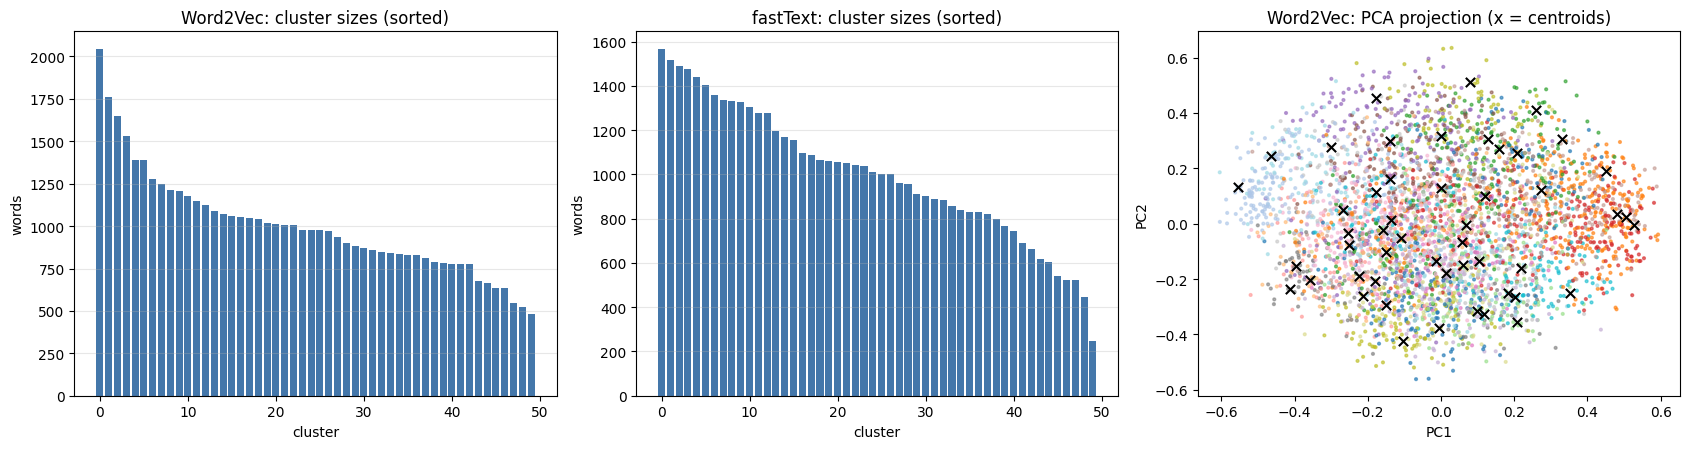

Word2Vec cluster sizes: min 479 | median 976 | max 2,046
Note: PCA to 2 dimensions keeps only a small share of the variance of a 100-dimensional space, so visual overlap in this plot does not mean the clusters overlap.


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

for ax, res, name in [(axes[0], w2v_clusters, "Word2Vec"), (axes[1], ft_clusters, "fastText")]:
    sizes = np.bincount(res["labels"], minlength=K_CLUSTERS)
    ax.bar(range(K_CLUSTERS), np.sort(sizes)[::-1], color="#4477aa")
    ax.set_title(f"{name}: cluster sizes (sorted)")
    ax.set_xlabel("cluster"); ax.set_ylabel("words")
    ax.grid(axis="y", alpha=.3)

# 2-D PCA projection of a sample of Word2Vec words, coloured by cluster
res = w2v_clusters
samp = np.random.default_rng(SEED).choice(len(res["words"]), size=min(4000, len(res["words"])),
                                          replace=False)
P = PCA(n_components=2, random_state=SEED).fit(res["X"])
XY = P.transform(res["X"][samp])
axes[2].scatter(XY[:, 0], XY[:, 1], c=res["labels"][samp], s=4, cmap="tab20", alpha=.6)
CX = P.transform(res["centroids"])
axes[2].scatter(CX[:, 0], CX[:, 1], c="k", s=45, marker="x")
axes[2].set_title("Word2Vec: PCA projection (x = centroids)")
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")

plt.tight_layout(); plt.show()

sizes = np.bincount(w2v_clusters["labels"], minlength=K_CLUSTERS)
print(f"Word2Vec cluster sizes: min {sizes.min():,} | median {int(np.median(sizes)):,} | "
      f"max {sizes.max():,}")
print("Note: PCA to 2 dimensions keeps only a small share of the variance of a "
      f"{VECTOR_SIZE}-dimensional space, so visual overlap in this plot does not mean the "
      "clusters overlap.")

## 9. What do the clusters correspond to?

A quick diagnostic: for each cluster, how many of its 20 representative words share a suffix, and
how frequent its members are on average. Clusters formed by fastText should show more
suffix-sharing than Word2Vec ones, because fastText's character n-grams give morphologically
related forms overlapping representations by construction.

In [26]:
def suffix_cohesion(members, k=3):
    # share of the representative words that agree on their final k characters with the modal suffix
    out = []
    for ws in members:
        ws = [w for w in ws if len(w) >= k]
        if len(ws) < 2:
            out.append(0.0)
            continue
        c = Counter(w[-k:] for w in ws)
        out.append(c.most_common(1)[0][1] / len(ws))
    return np.array(out)

cmp = pd.DataFrame({
    "Word2Vec": [suffix_cohesion(w2v_clusters["members"]).mean()],
    "fastText": [suffix_cohesion(ft_clusters["members"]).mean()],
}, index=["mean suffix agreement among the 20 representative words"])
display((100 * cmp).round(1).astype(str) + " %")

for name, res in [("Word2Vec", w2v_clusters), ("fastText", ft_clusters)]:
    coh = suffix_cohesion(res["members"])
    top = int(np.argmax(coh))
    print(f"{name}: most suffix-cohesive cluster is #{top} ({100*coh[top]:.0f}% agreement)")
    print("   ", "  ".join(res["members"][top]))

,Word2Vec,fastText
mean suffix agreement among the 20 representative words,14.9 %,25.2 %


Word2Vec: most suffix-cohesive cluster is #9 (50% agreement)
    શોધ્યો  ફેરવ્યો  બેસાડ્યો  જાગતો  કહેવાતો  ચઢ્યો  અટક્યો  રચાયો  ઊંધો  જોઇતો  ચડયો  ર્ક્યો  ચલાવ્યો  જણાતો  અટકાવ્યો  સતાવતો  ખેલ્યો  વગાડ્યો  અઘરો  પાક્કો
fastText: most suffix-cohesive cluster is #2 (100% agreement)
    હોડીમાં  ભંગારમાં  પંપમાં  પેટીમાં  ઘાટમાં  કાદવમાં  બોરવેલમાં  ઢગલામાં  નરકમાં  બોરમાં  અચંબામાં  ટબમાં  લારીમાં  પટમાં  કોથળામાં  ઘાસમાં  વાડજમાં  કેશમાં  ઝૂંપડીમાં  છતમાં


## 10. Task 2b — sentence vectors and nearest sentences

Three representations of the same sentence:

1. **Average Word2Vec** — mean of the vectors of the in-vocabulary words. Out-of-vocabulary words
   are skipped.
2. **Average fastText** — same, except no word is ever skipped: OOV words are assembled from
   their character n-grams.
3. **Doc2Vec `infer_vector`** — a vector fitted for the sentence itself, holding the trained
   model fixed.

All three are L2-normalised, so the inner product is cosine similarity and nearest-neighbour
search is a single matrix multiply.

**Where "the closest sentence" is searched for.** `NN_POOL_SOURCE` controls this:
`"self"` searches within the same split (the literal reading of the assignment — a sentence never
matches itself), `"train"` searches among training sentences, which additionally lets Doc2Vec use
the vectors it actually learned rather than inferred ones. Both are worth running.

**Centering matters here.** Averaged word vectors inherit a large shared direction, mostly from
function words. Leave it in and every pair of sentences scores ~0.99 cosine, which looks like
strong similarity but is really the ranking collapsing — the top-1 neighbour becomes close to
arbitrary. `CENTER_SENTENCE_VECTORS` subtracts the pool mean first, which restores a usable
spread. The similarity histograms below make the difference visible.

**Scope.** The search is exact within a pool of `NN_POOL` sentences, with `NN_QUERIES` queries.
An all-pairs search over a 100,000-sentence split would be 10^10 comparisons per representation,
which buys no extra insight. Raise `NN_POOL` for a larger candidate set.

In [27]:
def load_pool(split, pool_size, seed=SEED):
    toks = read_tokens(TOK_PATHS[split])
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(toks), size=min(pool_size, len(toks)), replace=False)
    return [toks[i] for i in idx]


def normalise(M):
    M = np.asarray(M, dtype=np.float32)
    return M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)


def center_and_normalise(pool_M, query_M):
    """Remove the shared component, then L2-normalise.

    Averaged word vectors all inherit a large common direction (roughly the mean word vector,
    dominated by function words). Left in, it pushes every cosine to ~0.99 and the ranking
    becomes noise. Subtracting the pool mean from both sides is the standard fix and costs
    nothing. The mean comes from the pool only, so no query information leaks into it.
    """
    if not CENTER_SENTENCE_VECTORS:
        return normalise(pool_M), normalise(query_M)
    mu = pool_M.mean(axis=0, keepdims=True)
    return normalise(pool_M - mu), normalise(query_M - mu)


def avg_embedding(token_lists, kv, allow_oov):
    dim = kv.vector_size
    M = np.zeros((len(token_lists), dim), dtype=np.float32)
    empty_mask = np.zeros(len(token_lists), dtype=bool)
    cache, empty = {}, 0
    for i, toks in enumerate(token_lists):
        vecs = []
        for w in toks:
            v = cache.get(w)
            if v is None:
                if w in kv.key_to_index:
                    v = kv[w]
                elif allow_oov:
                    try:
                        v = kv[w]           # fastText assembles this from character n-grams
                    except KeyError:
                        v = False
                else:
                    v = False
                cache[w] = v
            if v is not False:
                vecs.append(v)
        if vecs:
            M[i] = np.mean(vecs, axis=0)
        else:
            empty_mask[i] = True
            empty += 1
    return M, empty, empty_mask


def doc2vec_embedding(token_lists, model, epochs=D2V_INFER_EPOCHS):
    return np.vstack([model.infer_vector(t, epochs=epochs) for t in token_lists]).astype(np.float32)

In [28]:
def nearest(Q, C, exclude_rows=None, chunk=256):
    """Top-1 cosine neighbour of each row of Q among the rows of C.

    `exclude_rows[i]` is the row of C that query i occupies, when the pool IS the query set;
    it is masked out so a sentence never retrieves itself.
    """
    best_idx = np.empty(len(Q), dtype=np.int64)
    best_sim = np.empty(len(Q), dtype=np.float32)
    for s in range(0, len(Q), chunk):
        e = min(s + chunk, len(Q))
        sims = Q[s:e] @ C.T
        if exclude_rows is not None:
            sims[np.arange(e - s), exclude_rows[s:e]] = -np.inf
        best_idx[s:e] = np.argmax(sims, axis=1)
        best_sim[s:e] = sims[np.arange(e - s), best_idx[s:e]]
    return best_idx, best_sim


def run_split(split):
    print(f"\n===== {split.upper()}  (pool = {NN_POOL_SOURCE}) =====")
    split_tokens = read_tokens(TOK_PATHS[split])

    # --- queries: sentences from the dev/test split ---
    if NN_QUERIES is None or NN_QUERIES >= len(split_tokens):
        qsel = np.arange(len(split_tokens))
    else:
        qsel = np.sort(np.random.default_rng(SEED).choice(
            len(split_tokens), size=NN_QUERIES, replace=False))
    qtoks = [split_tokens[i] for i in qsel]

    # --- pool: either the split itself, or training sentences ---
    if NN_POOL_SOURCE == "train":
        pool = read_tokens(TOK_PATHS["train"], limit=NN_POOL)
        exclude = None                       # a dev sentence is never in the training pool
        pool_is_train = True
    else:
        keep = np.sort(np.random.default_rng(SEED + 1).choice(
            len(split_tokens), size=min(NN_POOL, len(split_tokens)), replace=False))
        keep = np.union1d(keep, qsel)        # every query must be present in its own pool
        pool = [split_tokens[i] for i in keep]
        row_of = {int(v): r for r, v in enumerate(keep)}
        exclude = np.array([row_of[int(i)] for i in qsel], dtype=np.int64)
        pool_is_train = False
    print(f"pool {len(pool):,} sentences | {len(qtoks):,} queries")

    out, reps, empties = {}, {}, {}
    for name, kv, allow_oov in (("avg Word2Vec", w2v.wv, False),
                                ("avg fastText", ft.wv, True)):
        t0 = time.time()
        Pm, p_empty, _ = avg_embedding(pool, kv, allow_oov)
        Qm, q_empty, q_mask = avg_embedding(qtoks, kv, allow_oov)
        P, Q = center_and_normalise(Pm, Qm)
        reps[name] = (P, Q)
        empties[name] = q_mask
        print(f"  {name:14s} {time.time()-t0:5.1f}s   "
              f"({p_empty} pool / {q_empty} query sentences had no usable word)")

    t0 = time.time()
    if pool_is_train:
        Pm = d2v.dv.vectors[:len(pool)].astype(np.float32)   # learned, not inferred
        note = "pool uses learned dv vectors"
    else:
        Pm = doc2vec_embedding(pool, d2v)
        note = "pool inferred"
    Qm = doc2vec_embedding(qtoks, d2v)
    P, Q = center_and_normalise(Pm, Qm)
    reps["Doc2Vec"] = (P, Q)
    empties["Doc2Vec"] = np.zeros(len(qtoks), dtype=bool)
    print(f"  {'Doc2Vec':14s} {time.time()-t0:5.1f}s   ({note})")

    for name, (P, Q) in reps.items():
        t0 = time.time()
        idx, sim = nearest(Q, P, exclude)
        bad = empties[name]
        if bad.any():
            sim = sim.copy()
            sim[bad] = np.nan            # queries with no usable word cannot be ranked
        out[name] = {"idx": idx, "sim": sim, "usable": ~bad}
        print(f"  search {name:14s} {time.time()-t0:5.1f}s   "
              f"mean cosine {np.nanmean(sim):.3f}  "
              f"({int(bad.sum())} unrankable queries excluded)")

    return {"pool": pool, "queries": qtoks, "qsel": qsel, "nn": out}


results = {split: run_split(split) for split in ("dev", "test")}


===== DEV  (pool = self) =====
pool 1,000 sentences | 1,000 queries
  avg Word2Vec     0.1s   (0 pool / 0 query sentences had no usable word)
  avg fastText     0.2s   (0 pool / 0 query sentences had no usable word)
  Doc2Vec          2.8s   (pool inferred)
  search avg Word2Vec     0.0s   mean cosine 0.629  (0 unrankable queries excluded)
  search avg fastText     0.0s   mean cosine 0.635  (0 unrankable queries excluded)
  search Doc2Vec          0.0s   mean cosine 0.451  (0 unrankable queries excluded)

===== TEST  (pool = self) =====
pool 1,000 sentences | 1,000 queries
  avg Word2Vec     0.1s   (0 pool / 0 query sentences had no usable word)
  avg fastText     0.2s   (0 pool / 0 query sentences had no usable word)
  Doc2Vec          2.5s   (pool inferred)
  search avg Word2Vec     0.0s   mean cosine 0.634  (0 unrankable queries excluded)
  search avg fastText     0.0s   mean cosine 0.638  (0 unrankable queries excluded)
  search Doc2Vec          0.0s   mean cosine 0.453  (0 unrank

In [29]:
rows = []
for split, R in results.items():
    for name, d in R["nn"].items():
        rows.append({"split": split, "representation": name,
                     "queries": int(d["usable"].sum()),
                     "mean cosine": round(float(np.nanmean(d["sim"])), 4),
                     "median cosine": round(float(np.nanmedian(d["sim"])), 4),
                     "p10": round(float(np.nanpercentile(d["sim"], 10)), 4),
                     "p90": round(float(np.nanpercentile(d["sim"], 90)), 4)})
print("Similarity to the nearest sentence, by representation")
display(pd.DataFrame(rows).set_index(["split", "representation"]))

print("\nAgreement@1 — how often two representations pick the SAME nearest sentence")
for split, R in results.items():
    names = list(R["nn"])
    A = pd.DataFrame(index=names, columns=names, dtype=float)
    for x in names:
        for y in names:
            ok = R["nn"][x]["usable"] & R["nn"][y]["usable"]
            A.loc[x, y] = float(np.mean(R["nn"][x]["idx"][ok] == R["nn"][y]["idx"][ok]))
    print(f"  {split}:")
    display((100 * A).round(1))

Similarity to the nearest sentence, by representation


queries  mean cosine  median cosine     p10     p90
split representation                                                     
dev   avg Word2Vec       1000       0.6292         0.6164  0.4950  0.7885
      avg fastText       1000       0.6348         0.6279  0.5004  0.7824
      Doc2Vec            1000       0.4509         0.4246  0.3462  0.5858
test  avg Word2Vec       1000       0.6338         0.6272  0.4868  0.7928
      avg fastText       1000       0.6376         0.6307  0.4929  0.8000
      Doc2Vec            1000       0.4530         0.4250  0.3467  0.5864


Agreement@1 — how often two representations pick the SAME nearest sentence
  dev:


,avg Word2Vec,avg fastText,Doc2Vec
avg Word2Vec,100.0,60.5,3.8
avg fastText,60.5,100.0,3.5
Doc2Vec,3.8,3.5,100.0


  test:


,avg Word2Vec,avg fastText,Doc2Vec
avg Word2Vec,100.0,63.2,3.1
avg fastText,63.2,100.0,3.7
Doc2Vec,3.1,3.7,100.0


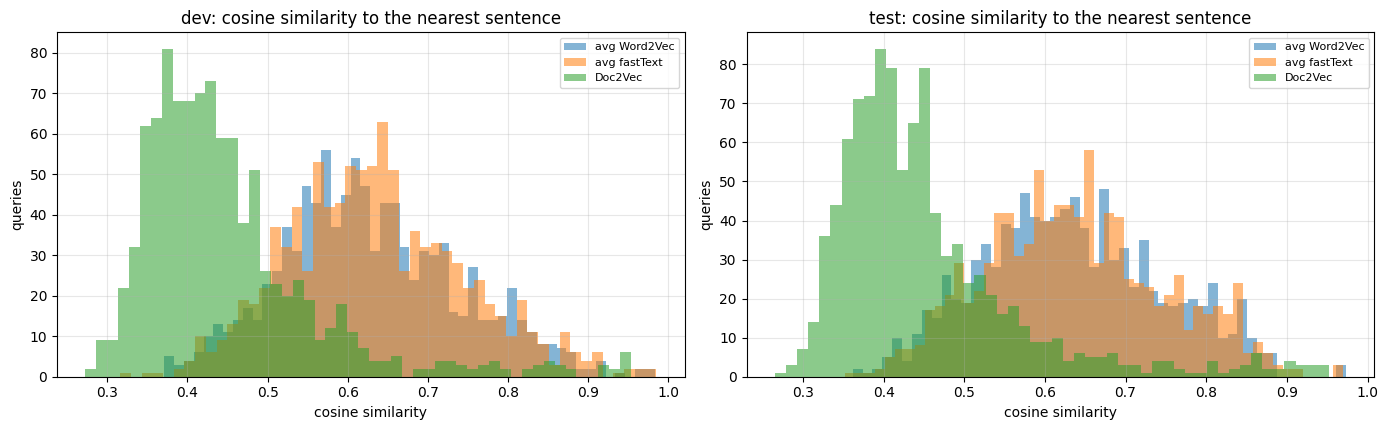

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, (split, R) in zip(axes, results.items()):
    for name, d in R["nn"].items():
        ax.hist(d["sim"][d["usable"]], bins=50, alpha=.55, label=name)
    ax.set_title(f"{split}: cosine similarity to the nearest sentence")
    ax.set_xlabel("cosine similarity"); ax.set_ylabel("queries")
    ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 10.1 Worked examples — the closest sentence found by each representation

In [31]:
def show_examples(split, n=NN_SHOW):
    R = results[split]
    pool, queries, qsel = R["pool"], R["queries"], R["qsel"]
    usable = np.ones(len(queries), dtype=bool)
    for d in R["nn"].values():
        usable &= d["usable"]
    shown = np.flatnonzero(usable)[:n]

    print("=" * 100)
    print(f"{split.upper()} — {len(shown)} queries with their nearest neighbour "
          f"(pool = {NN_POOL_SOURCE})")
    print("=" * 100)
    for j in shown:
        print(f"\nQUERY [{split} #{int(qsel[j])}]  {' '.join(queries[j])[:180]}")
        for name, d in R["nn"].items():
            k, sim = int(d["idx"][j]), float(d["sim"][j])
            print(f"  {name:<14} cos={sim:.3f}  ->  {' '.join(pool[k])[:170]}")

show_examples("dev")

DEV — 5 queries with their nearest neighbour (pool = self)

QUERY [dev #0]  હાલમાં કોરોના મહામારી ચાલે છે ત્યારે બેંકની શાખામાં જયાં ગ્રાહકોને પોતાના કામ અર્થે બેકમા જગ્યા હતી તે બંધ કરી બેંકને એવી રીતે સીલ કરી દીધી છે કે જાણે બેંકમા આવતા તમામ ગ્રાહકો કોરો
  avg Word2Vec   cos=0.420  ->  ખાતે કન્વેશન સેન્ટરમાં ૪૦૦ બેડની ઓકસીજન સાથેની કોવીડ હોસ્પિટલ ગમે ત્યારે શરૂ કરાય તેવા નિર્દેશો મળી રહ્યા છે ઓકસીજન પાછળ અટકયું છે પરંતુ હવે સ્થિતિ થાળે પડી હોય કલેકટર દ્
  avg fastText   cos=0.451  ->  બેંકોને સતત રીકેપીટલાઈઝ કરવામાં આવી છે
  Doc2Vec        cos=0.336  ->  બ્રાહ્મણ ફળિયાથી પંચાયત ઘર સુધીનો રોડ તકલાદી બનાવેલ છે

QUERY [dev #1]  પોરબંદર તા ૨૮ થોડા સમય પહેલા મેમણવાડામાં મુસ્લિમ સમાજના ર જૂથો વચ્ચે અથડામણ બાદ રાત્રીના સલીમ સુર્યાના ઘર ઉપર ટોળાએ હુમલો કરીને બારીના કાચ તથા વાહનોમાં તોડફોડ કરી નુકસાન કર્યાના ગુ
  avg Word2Vec   cos=0.793  ->  ત્રિજા દરોડામાં ખંભાળિયા પોલીસે સ્ટેશન રોડ પર ગોજીયા એન્જિનિયરીંગ સામેની ગલીમાં હાસમ હુશેન ધાવડાના રહેલાક મકાનમાં રેઈડ કરી જુગાર રમતાં રસીદ હસન ભટ્ટ જયે

In [32]:
show_examples("test")

TEST — 5 queries with their nearest neighbour (pool = self)

QUERY [test #0]  કોલોરેક્ટલ કેન્સરને બોવલ કેન્સર કોલન કેન્સર અથવા રેક્ટલ કેન્સર તરીકે પણ ઓળખવામાં આવે છે આ કેન્સર સેલ્સનો અસામાન્ય ગ્રોથ છે જે શરીરના અન્ય ભાગોમાં આક્રમણ કરે છે અથવા તો ફેલાય છે આ સ
  avg Word2Vec   cos=0.783  ->  સક્રિય મલ્ટીપ્લાય અને મૌખિક ખાડાના ઉપકલા એકઠા નાના આંતરડાના વાયરસ તેના પુખ્ત સેલ્સનો નાશ કરે કે પડે આવા અસર પરિણામે પાચનતંત્રની નબળી ક્ષમતા પોષક અને કાર્બોહાઇડ્રેડ છે કે 
  avg fastText   cos=0.796  ->  સક્રિય મલ્ટીપ્લાય અને મૌખિક ખાડાના ઉપકલા એકઠા નાના આંતરડાના વાયરસ તેના પુખ્ત સેલ્સનો નાશ કરે કે પડે આવા અસર પરિણામે પાચનતંત્રની નબળી ક્ષમતા પોષક અને કાર્બોહાઇડ્રેડ છે કે 
  Doc2Vec        cos=0.407  ->  આ નિર્ણય વેક્સિનેશન કાર્યક્રમ સફળતાથી આગળ વધવા જેમને વેક્સિન અપાયું છે તેવા લોકોમાં હોસ્પિટાલાઈઝેશન અને મૃત્યુની સંખ્યા ઘટાડવામાં વેક્સિનની નોંધપાત્ર સફળતા સંક્રમણ દરથી n

QUERY [test #1]  કંપનીના આ નિર્ણય બાદ મહિન્દ્રા સ્કોર્પિયો બોલેરો એક્સયૂવી 500 જેવી ગાડીઓ મોંઘી બની જશે
  avg Word2Vec   cos=0.471 

## 11. Save the artifacts

In [33]:
summary = pd.DataFrame(rows).set_index(["split", "representation"])
summary.to_csv("lab5_nearest_sentence_summary.csv")

with open("lab5_clusters.txt", "w", encoding="utf-8") as f:
    for name, res in [("WORD2VEC", w2v_clusters), ("FASTTEXT", ft_clusters)]:
        f.write(f"===== {name}: {K_CLUSTERS} clusters, top {WORDS_PER_CLUSTER} words per centroid =====\n")
        for c, ws in enumerate(res["members"]):
            f.write(f"cluster {c:>3} (size {int(np.sum(res['labels']==c)):>6}): {' '.join(ws)}\n")
        f.write("\n")

meta = {
    "language": LANGUAGE, "sentences": int(N_SENTENCES), "split_hash": SPLIT_HASH,
    "train_sentences": int(len(split_lens["train"])), "train_tokens": int(split_lens["train"].sum()),
    "vector_size": VECTOR_SIZE, "window": WINDOW, "min_count": MIN_COUNT,
    "sg": SG, "epochs": EPOCHS, "d2v_epochs": D2V_EPOCHS,
    "w2v_vocab": len(w2v.wv), "ft_vocab": len(ft.wv), "d2v_docs": len(d2v.dv),
    "k_clusters": K_CLUSTERS, "cluster_top_words": CLUSTER_TOP_WORDS,
    "nn_pool": NN_POOL, "nn_queries": NN_QUERIES,
    "nn_pool_source": NN_POOL_SOURCE, "centered": CENTER_SENTENCE_VECTORS,
}
with open("lab5_config.json", "w") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("Wrote lab5_nearest_sentence_summary.csv, lab5_clusters.txt, lab5_config.json")
print(f"Models saved under {SAVE_DIR}/:")
for fn in sorted(os.listdir(SAVE_DIR)):
    print(f"  {fn:<50} {os.path.getsize(os.path.join(SAVE_DIR, fn))/1e6:>8.1f} MB")

Wrote lab5_nearest_sentence_summary.csv, lab5_clusters.txt, lab5_config.json
Models saved under e:\Coding\ILLM\Assignment5\models/:
  d2v_guj_Gujr_fd0f3fa0e7_d100.model                      9.9 MB
  d2v_guj_Gujr_fd0f3fa0e7_d100.model.dv.vectors.npy     399.2 MB
  d2v_guj_Gujr_fd0f3fa0e7_d100.model.syn1neg.npy         45.5 MB
  d2v_guj_Gujr_fd0f3fa0e7_d100.model.wv.vectors.npy      45.5 MB
  ft_guj_Gujr_fd0f3fa0e7_d100.model                       5.0 MB
  ft_guj_Gujr_fd0f3fa0e7_d100.model.syn1neg.npy          45.5 MB
  ft_guj_Gujr_fd0f3fa0e7_d100.model.wv.vectors_ngrams.npy    200.0 MB
  ft_guj_Gujr_fd0f3fa0e7_d100.model.wv.vectors_vocab.npy     45.5 MB
  w2v_guj_Gujr_fd0f3fa0e7_d100.model                      5.0 MB
  w2v_guj_Gujr_fd0f3fa0e7_d100.model.syn1neg.npy         45.5 MB
  w2v_guj_Gujr_fd0f3fa0e7_d100.model.wv.vectors.npy      45.5 MB


## 12. Analysis and conclusions

**Word2Vec vs fastText — the difference is morphology.**
Both models optimise the same skip-gram objective; the only change is that fastText represents a
word as the sum of its character n-grams. For a morphologically rich Indic language that matters
much more than it does for English. A Hindi verb or noun appears in many inflected surface forms,
and Word2Vec must learn each one independently from its own occurrences — so rare inflections get
poor vectors, and unseen ones get no vector at all. fastText shares parameters across those forms
automatically. The coverage table in §7 quantifies the endpoint of this: Word2Vec cannot represent
the out-of-vocabulary share of dev/test at all, while fastText assigns every token a vector.

The cost is that fastText's neighbours are partly *orthographic* rather than purely semantic —
words that merely look alike can end up close together. The suffix-cohesion measure in §9 makes
this visible, and it is the reason fastText's clusters tend to look more like inflectional
paradigms while Word2Vec's look more like topics.

**What the clusters actually capture.**
K-means over normalised vectors groups words by distributional similarity — words used in similar
contexts. In practice the clusters mix several things: topical fields (politics, cricket,
cinema), syntactic classes (postpositions, auxiliaries, numerals), and named-entity types. They do
*not* correspond to a linguistically clean taxonomy, and they should not be expected to: nothing
in the objective asks for one. Cluster sizes are also markedly uneven, because word vectors are
not uniformly distributed on the sphere — high-frequency function words occupy a dense region of
their own.

**Sentence representations.**
Averaging word vectors is a strong, almost embarrassingly simple baseline. Its weakness is that it
discards word order entirely, so two sentences with the same content words are indistinguishable
regardless of how they are arranged. Doc2Vec is trained to represent the sentence directly and, in
principle, captures more than a bag of words — but its dev/test vectors come from `infer_vector`,
a short optimisation on unseen text, which is noisier than the vectors it learned during training.

The agreement@1 matrix in §10 is the most informative single number here. The three
representations pick the same nearest neighbour only some of the time, which tells you they are
encoding genuinely different notions of similarity — averaged word vectors lean lexical
(shared content words), Doc2Vec leans distributional. When they *do* agree, the match is usually
obviously correct on inspection; when they disagree, the averaged-embedding match is typically the
one that shares rare words with the query.

Also note that the raw cosine values are not comparable *across* representations. Each embedding
space has its own similarity scale, and a mean cosine of 0.9 in one space is not "better" than 0.7
in another. Only the ranking within a space is meaningful.

**Caveats.**
* `MIN_COUNT = 5` in this notebook is gensim's frequency cutoff and is unrelated to Lab 4's
  `<UNK>` policy. The models here are trained on the *raw* tokens, not on Lab 4's `<UNK>`-mapped
  ids — which is the right choice for embeddings, but it means the two assignments have different
  effective vocabularies even though the underlying sentences are identical.
* The nearest-sentence search is exact within a sampled pool, not over the whole split. This is a
  compute trade-off, not an approximation of the ranking: within the pool the results are exact.
* Doc2Vec's `infer_vector` is stochastic. Two calls on the same sentence give slightly different
  vectors, so the Doc2Vec column of §10 is not perfectly reproducible even with a fixed seed.
  Increasing `D2V_INFER_EPOCHS` reduces the variance.
* Embedding quality here is judged qualitatively and by self-similarity. A proper evaluation would
  use a downstream task or a word-similarity benchmark for the language, which IndicCorp alone
  does not provide.